# Pandas Series — Session 16

Up to this point, every program you have written has been built from the fundamentals: variables, lists, dictionaries, functions, conditionals, loops, and finally NumPy arrays for fast numerical work. Now we climb the next rung of the data science ladder: pandas. If NumPy provides raw speed and arrays, pandas provides meaning. It wraps data in a structure that knows both the values AND the labels attached to them. Pandas is, in its own words, a fast, powerful, flexible and easy-to-use open source data analysis and manipulation tool built on top of the Python programming language.

The two most important structures in pandas are the **Series** and the **DataFrame**. Think of an Excel sheet: a single column, with a header on top and row numbers on the left, is essentially a Series. The whole sheet, with many columns sharing the same row labels, is a DataFrame. This session focuses completely on the Series — the one-dimensional labeled array — because almost every pandas operation you will ever run eventually reduces to working on a Series.

Here is the roadmap for the session:

1. What pandas is and how to import it.
2. Creating a Series from a list, with an automatic index that runs from 0 to n minus 1.
3. Giving a Series a custom index and a name.
4. Building a Series directly from a dictionary, where keys become labels.
5. Inspecting a Series with attributes such as size, dtype, name, is_unique, index, and values.
6. Loading a single-column CSV straight into a Series with read_csv.
7. Copying data safely so that editing a subset never mutates the original by accident.
8. Previewing and sorting with head, tail, sample, value_counts, and both sort methods.
9. Using maths methods such as count, sum, mean, median, mode, std, var, and describe.
10. Indexing, slicing, and editing values, including adding brand-new labels.
11. Connecting a Series to everyday Python: len, dict, membership, and broadcasting.
12. Boolean filtering to answer real questions such as: how many fifties did a batsman score?
13. Plotting a Series in a single line.
14. A toolbox of important methods: isin, apply, astype, between, clip, and the families that handle duplicates and missing values.

By the end you will think of a Series not as a plain list but as labeled data — values plus names — and you will be able to load, inspect, filter, compute on, and plot it using only a handful of expressive commands.

# 1. Introducing Pandas

### Pandas fundamentals
Labeled axes, alignment, indexing, grouping, missing data, I/O. Critical for EDA/preprocessing.

### AI/ML relevance
Shapes, dtypes, vectorization, indexing, and clean tabular ops are critical for reliable data pipelines.

## 1.1 Importing pandas

Pandas is built on top of NumPy, so in almost every notebook that uses pandas you will see the two imports that open this session:

```python
import numpy as np
import pandas as pd
```

The `import pandas as pd` line creates the pandas module under a short alias, so that every time you need a pandas function you write `pd.` instead of the longer full name. The `import numpy as np` line is just as important because pandas stores its underlying numeric data in NumPy arrays, and a lot of pandas behaviour — vectorized operations, broadcasting, and dtype handling — is really NumPy behaviour wearing a pandas coat.

Why an alias at all? Consider how often you will type `pd.Series(...)` or `pd.read_csv(...)` in a single analysis. Heavy modules are almost always imported with a short, conventional alias: `np` for NumPy and `pd` for pandas. If you see code that says `from pandas import Series`, it works too, but the `pd.` prefix is far more common and it clearly advertises where each function lives.

One mental model that will help throughout this session: a pandas Series is a NumPy array plus a set of labels. The labels are the index, and together they give the data meaning. Everything you loved about fast, vectorized NumPy still works under the hood, but now each element can also be found by a name.

In [1]:
import numpy as np
import pandas as pd

# 2. Series from Lists

### Pandas fundamentals
Labeled axes, alignment, indexing, grouping, missing data, I/O. Critical for EDA/preprocessing.

## 2.1 The labeled array

The very first thing the code does is wrap an ordinary Python list in `pd.Series(...)`:

```python
country = ['India', 'Pakistan', 'USA', 'Nepal', 'Srilanka']
pd.Series(country)
```

When you print such a Series, pandas shows you two things side by side. On the left is the **index** — the labels — and on the right is each **value**. Because we did not supply labels, pandas creates a default index automatically: `0, 1, 2, 3, 4`. This is called a RangeIndex, and it behaves much like list positions. The vertical arrangement matters: row 0 of the index holds `'India'`, row 1 holds `'Pakistan'`, and so on.

Second, notice the bottom line: `dtype: object`. Since the list contains text, pandas stores it as the general object dtype rather than a numeric one. If the list had contained integers, you would see `dtype: int64` instead. So a Series can hold data of any type — strings, integers, floats, and even Python objects — which is exactly why pandas describes a Series as a one-dimensional array that can hold data of any type.

Think of a Series as an Excel column: the row numbers on the striped bar are the index, the cells are the values, and the column header (which we meet later as the Series name) sits at the top. Everything pandas does from here on — slicing, filtering, grouping, plotting — assumes this labeled column as its basic unit.

## 2.2 Dtype inference on creation

Run the string example and then the integer example and compare what pandas reports:

```python
pd.Series(['India', 'Pakistan', 'USA'])
pd.Series([13, 24, 56, 78, 100])
```

The first prints `dtype: object`; the second prints `dtype: int64`. Pandas looks at every value in the list and picks the narrowest dtype that can represent all of them. This is called dtype inference. A list of integers becomes int64, a list of floats or a mixture containing a float becomes float64, and text becomes object.

Why care? Your dtype decides which operations are legal and how much memory the Series consumes. Integer and float dtypes let you sum, average, and compare the values with fast vectorized NumPy routines. An object dtype mostly forces slower, element-by-element handling. This is the first hint of a theme that will return in `astype` and the category dtype: the right dtype makes your analysis correct AND fast.

There is also a small but important detail hiding in this section: the Series that holds runs is assigned to a variable, `runs_ser`. The string Series was created inline and never stored. In later cells you will rely on `runs_ser`, so storing the result of `pd.Series(...)` is the normal way to keep data around. An inline creation is useful for a quick peek; a named variable is what you need for real work.

In [2]:
# string
country = ['India','Pakistan','USA','Nepal','Srilanka']

pd.Series(country)

0       India
1    Pakistan
2         USA
3       Nepal
4    Srilanka
dtype: str

In [3]:
# integers
runs = [13,24,56,78,100]

runs_ser = pd.Series(runs)

# 3. Custom Index and Name

## 3.1 Why labels matter

So far the Series used a default 0-to-n index. But the whole point of a labeled array is that the labels can carry meaning. Here the code attaches subject names to marks and a title to the whole column:

```python
marks = [67, 57, 89, 100]
subjects = ['maths', 'english', 'science', 'hindi']
pd.Series(marks, index=subjects, name='Nitish ke marks')
```

The `index=` parameter maps one number to each label: `67` belongs to `'maths'`, `57` to `'english'`, and so on. The lists must have the same length — pandas raises a ValueError otherwise, because it would not know which label belongs to which value.

The `name=` parameter gives the whole Series a title. It appears at the bottom of the printed output, like `Name: Nitish ke marks, dtype: int64`, and it becomes the column header if you later place this Series inside a DataFrame. A descriptive name is free documentation for you and for anyone reading your output.

Once labels exist, they are not just decoration. You can fetch a single value by its label with `marks_series['maths']`, exactly the way you would look up a dictionary key. And later in the course, when two Series interact, pandas will align them BY INDEX rather than by position — two Series sharing labels automatically line up their values. That is the superpower of labeled data, and it is why the Series keeps its index alongside the values at all times.

In [4]:
# custom index
marks = [67,57,89,100]
subjects = ['maths','english','science','hindi']

pd.Series(marks,index=subjects)

maths       67
english     57
science     89
hindi      100
dtype: int64

In [5]:
# setting a name
marks = pd.Series(marks,index=subjects,name='Nitish ke marks')
marks

maths       67
english     57
science     89
hindi      100
Name: Nitish ke marks, dtype: int64

# 4. Series from a Dictionary

### Pandas fundamentals
Labeled axes, alignment, indexing, grouping, missing data, I/O. Critical for EDA/preprocessing.

## 4.1 Dict keys become the index

If a Series is a labeled array, then a Python dictionary — keys and values — is a very natural way to describe it:

```python
marks = {'maths': 67, 'english': 57, 'science': 89, 'hindi': 100}
pd.Series(marks, name='nitish ke marks')
```

When you pass a dict to `pd.Series(...)`, the dict keys become the index labels and the dict values become the Series values. No separate index list is needed, because the keys already ARE the labels. This is the most Pythonic of the creation routes: you write a label-value mapping once and pandas turns it into a labeled column.

A few practical details are worth storing. First, order is preserved. Since Python 3.7, dicts remember insertion order, and pandas builds the Series in that same order — mathematics, then english, science, hindi, in the exact order the dict was written.

The dtype is inferred from the values, exactly as in the list case. Here all four values are integers, so the Series is int64.

Second, this pattern composes beautifully with the real world. Configuration data, lookup tables, and small metadata maps are usually stored as dictionaries, and a single `pd.Series(dict)` turns any of them into an analysis-ready column.

Finally, note that you can still pass a `name=` even when building from a dictionary. The name lives on the Series itself, independent of the index, and it will be printed at the bottom of the output as the title of the column.

In [6]:
marks = {
    'maths':67,
    'english':57,
    'science':89,
    'hindi':100
}

marks_series = pd.Series(marks,name='nitish ke marks')
marks_series

maths       67
english     57
science     89
hindi      100
Name: nitish ke marks, dtype: int64

# 5. Series Attributes

### Pandas fundamentals
Labeled axes, alignment, indexing, grouping, missing data, I/O. Critical for EDA/preprocessing.

## 5.1 Introspecting a Series

Every pandas object carries metadata that describes its own structure. The attributes you will use constantly are:

| Attribute | Meaning |
|---|---|
| `size` | total number of elements |
| `dtype` | data type of the values |
| `name` | name of the series |
| `is_unique` | True when all values are distinct |
| `index` | the index (labels) object |
| `values` | the raw values as a NumPy array |

The cells run each one against `marks_series`: `size` returns 4, `dtype` returns int64, `name` returns the title string, and `is_unique` returns True because all the marks differ. The second `is_unique` example builds `pd.Series([1, 1, 2, 3, 4, 5])`, which contains a repeated 1, and correctly reports False.

`index` and `values` deserve special attention. `marks_series.index` returns an Index object holding the labels: `Index(['maths', 'english', 'science', 'hindi'], dtype='object')`. For the runs Series created without custom labels, `runs_ser.index` returns a RangeIndex(start=0, stop=5, step=1) — the compact representation of the labels 0 through 4.

`values`, by contrast, drops the labels entirely and returns the underlying NumPy array — `array([67, 57, 89, 100])`. If you ever need pure numbers for a fast library function that knows nothing about pandas, `series.values` is the door out of the pandas world.

## 5.2 Reading attributes in practice

Attributes are your first response when you meet an unfamiliar Series. The pattern is: create a Series, then interrogate it.

`marks_series.size` and `len(marks_series)` answer the same question, but size arrives through the pandas layer and is slightly cheaper on large arrays. `marks_series.dtype` tells you what kind of numbers or text you are holding and, as we saw, which operations will be fast. `name` tells you what the column represents — always worth printing before a long analysis. `is_unique` is the start of duplicate detection: if it is False, some values appear more than once and you may want to investigate.

The Index object returned by `.index` can hold custom labels (like subject names), and pandas makes no assumption that the labels are numbers. When labels are numbers 0 through n-1, pandas still stores them efficiently as a RangeIndex rather than as a list of separate integers.

Two extra attributes appear in the notes for this section and are worth knowing even though they are not run as separate cells. `.shape` returns the dimensions as a tuple — for a Series it is `(n,)`, one element followed by a comma — and `.hasnans` returns True if any value is missing. Together with size, dtype, and name, these form the metadata toolkit you will use at the start of every exploration: check the shape, check the type, check the name, check for missing values. Almost every data science workflow begins with a one-line structural report of the data you just loaded.

In [7]:
# size
marks_series.size

4

In [8]:
# dtype
marks_series.dtype

dtype('int64')

In [9]:
# name
marks_series.name

'nitish ke marks'

In [10]:
# is_unique
marks_series.is_unique

pd.Series([1,1,2,3,4,5]).is_unique

False

In [11]:
# index
marks_series.index

Index(['maths', 'english', 'science', 'hindi'], dtype='str')

In [12]:
runs_ser.index

RangeIndex(start=0, stop=5, step=1)

In [13]:
# values
marks_series.values

array([ 67,  57,  89, 100])

# 6. Loading a Series from CSV

### Pandas fundamentals
Labeled axes, alignment, indexing, grouping, missing data, I/O. Critical for EDA/preprocessing.

## 6.1 read_csv, squeeze, and index_col

Most real data does not begin as a list or a dict; it begins as a file. The standard entry point is `pd.read_csv(...)`. When the CSV holds a single meaningful column, pandas can deliver it directly as a Series:

```python
subs = pd.read_csv('/content/subs.csv', squeeze=True)
vk = pd.read_csv('/content/kohli_ipl.csv', index_col='match_no', squeeze=True)
movies = pd.read_csv('/content/bollywood.csv', index_col='movie', squeeze=True)
```

The `subs.csv` file contains one data column, so with `squeeze=True` pandas turns the result into a Series instead of a one-column DataFrame; its name is the column header, `Subscribers gained`. Printing it shows the default RangeIndex 0 to 364 and dtype int64 — 365 daily values.

The `kohli_ipl.csv` file has two columns, a match number and a runs value. The trick is `index_col='match_no'`: that column becomes the index, and the remaining runs column becomes the Series values. The output then shows scores labeled by match number, with the Series named `runs`.

The `bollywood.csv` file associates each movie title with a lead actor. `index_col='movie'` makes the title the index, leaving the actor column as the values, and the Series is named `lead`.

This is the closest pandas gets to a dedicated 'Series from CSV' constructor: use `squeeze=True` when there is one column, and add `index_col=...` when a column should become the label axis. The result is data that arrives already labeled and ready for the methods in the rest of this session.

In [17]:
# with one col
subs = pd.read_csv('D:/GENAI/AI-Engineering-Foundations/01_Python/07_Pandas/Datasets/subs.csv')
subs

,Subscribers gained
0,48
1,57
2,40
3,43
4,44
...,...
360,231
361,226
362,155
363,144


In [18]:
subs = pd.read_csv('D:/GENAI/AI-Engineering-Foundations/01_Python/07_Pandas/Datasets/subs.csv').squeeze()
subs

0       48
1       57
2       40
3       43
4       44
      ... 
360    231
361    226
362    155
363    144
364    172
Name: Subscribers gained, Length: 365, dtype: int64

# 7. Copy versus Views

## 7.1 The trap of shared data

Pandas frequently avoids copying data. Instead, a derived object may be a **view** that points at the same underlying memory as its source. The cells demonstrate the trap with `vk.head()`:

```python
new = vk.head()
new[1] = 1
```

`vk.head()` takes the first five rows of the batting runs Series. Assigning `new[1] = 1` looks harmless — a local change to a small preview. But because `new` is a view, the write travels straight back into the original `vk`, silently changing the original's second value. A beginner reads this code and expects the original to be untouched; pandas, for efficiency, shares the underlying data instead of copying it.

The rule is simple: when you plan to MODIFY a subset of data, make an independent copy first with `.copy()`:

```python
new = vk.head().copy()
new[1] = 100
```

Now `new` owns its own storage. Setting `new[1] = 100` changes only the copy, and the printed original `vk` still shows its untouched values. This is also the seed of a warning you will meet in DataFrames: chained assignment, where the selection and the write happen in separate steps, triggers pandas' `SettingWithCopyWarning` precisely because it is impossible to tell at a glance whether you are editing a view or a copy. Internalize the habit now — copy before you modify — and you will avoid a whole class of silent bugs.

## 7.2 Making safe copies

When should you reach for `.copy()`? Whenever the object you are about to edit is derived from another object by filtering, slicing, or a chain of methods such as `head()` or `tail()`.

The safest workflow used by experienced pandas users is:

1. Read the data.
2. Take a preview with `head()` or `tail()` to verify it looks right.
3. If the preview is only for looking, keep it as is.
4. The moment a subset must be changed, call `.copy()` on it first.

The distinction between the two examples in this notebook is the entire lesson:

```python
new = vk.head()          # view - shares memory, edits leak into vk
new[1] = 1

new = vk.head().copy()   # independent object
new[1] = 100
```

The first block mutates the original silently; the second block is fully contained. The same semantics apply to `.loc` and `.iloc` selections, which you will learn later: a slice without `.copy()` is a window onto the original data.

This copy-versus-view behaviour is a classic interview topic, but more importantly it is a daily safety habit. Data cleaning pipelines often reload the same dataset many times, and an accidental view-write can corrupt a DataFrame you thought was unchanged. One `.copy()` call guarantees that your edits stay local, and the tiny memory cost is far cheaper than debugging a mystery mutation.

In [20]:
# with 2 cols
vk = pd.read_csv('D:/GENAI/AI-Engineering-Foundations/01_Python/07_Pandas/Datasets/kohli_ipl.csv')
vk

,match_no,runs
0,1,1
1,2,23
2,3,13
3,4,12
4,5,1
...,...,...
210,211,0
211,212,20
212,213,73
213,214,25


In [21]:
# with 2 cols
vk = pd.read_csv('D:/GENAI/AI-Engineering-Foundations/01_Python/07_Pandas/Datasets/kohli_ipl.csv',index_col='match_no').squeeze()
vk

match_no
1       1
2      23
3      13
4      12
5       1
       ..
211     0
212    20
213    73
214    25
215     7
Name: runs, Length: 215, dtype: int64

In [26]:
movies = pd.read_csv('D:/GENAI/AI-Engineering-Foundations/01_Python/07_Pandas/Datasets/bollywood.csv',index_col='movie').squeeze()
movies

movie
Uri: The Surgical Strike                   Vicky Kaushal
Battalion 609                                Vicky Ahuja
The Accidental Prime Minister (film)         Anupam Kher
Why Cheat India                            Emraan Hashmi
Evening Shadows                         Mona Ambegaonkar
                                              ...       
Hum Tumhare Hain Sanam                    Shah Rukh Khan
Aankhen (2002 film)                     Amitabh Bachchan
Saathiya (film)                             Vivek Oberoi
Company (film)                                Ajay Devgn
Awara Paagal Deewana                        Akshay Kumar
Name: lead, Length: 1500, dtype: str

# 8. Series Methods — Preview and Sort

### Pandas fundamentals
Labeled axes, alignment, indexing, grouping, missing data, I/O. Critical for EDA/preprocessing.

## 8.1 head, tail, sample, and value_counts

After loading real data, the first moves are preview and counting. The cells apply four workhorse methods.

`subs.head()` shows the first five rows, and `vk.head(3)` shows the first three. `vk.tail(10)` shows the last ten. Both take an optional count parameter and default to five. They are cheap ways to peek at the top and bottom of data and confirm the file loaded as expected.

`movies.sample(5)` returns five random rows — useful for a quick sanity check when the data has no natural top or bottom, or when you want a taste of the full range without bias. Each call picks different rows.

`movies.value_counts()` deserves special attention. It counts how many times each distinct value appears and returns a new Series whose index is the unique value and whose values are the frequencies, sorted descending. The output answers an immediate question: `Akshay Kumar` stars in 48 movies, `Amitabh Bachchan` in 45, `Ajay Devgn` in 38, then Salman Khan, Sanjay Dutt, and so on down to the actors who appear only once. It is the fastest possible way to understand the distribution of a categorical column.

Together these four methods form the standard greeting committee for any dataset: look at the head, glance at the tail, sample a few random rows, and count how common each category is.

## 8.2 sort_values and sort_index

Sorting brings order to a column. Two methods handle it: `sort_values` sorts by the VALUES, while `sort_index` sorts by the LABELS.

```python
vk.sort_values(ascending=False)
movies.sort_index(ascending=False, inplace=True)
vk.sort_values(inplace=True)
```

The first call sorts the runs Series from highest to lowest with `ascending=False`. Reading the output you can immediately see the top scores: match 128 with 113 runs, match 126 with 109, then 108, 100, 100, and so on down to the many zero-run matches. Confirming the top value is as easy as chaining `.head(1)`, which the notebook does to report the maximum, 113.

`sort_index(ascending=False)` rearranges by label instead — the bollywood Series becomes ordered by movie title from Z backwards to A. `movies.sort_index(ascending=False, inplace=True)` is special because `inplace=True` mutates the original Series: pandas sorts `movies` in place and returns nothing. The later `movies` prints confirm the titles now run from Zor Lagaa Ke...Haiya! downward.

The final cells show the complement: `vk.sort_values(inplace=True)` permanently sorts the runs from smallest to largest, so the zeros come first and the 113 appears last.

The keyword trio to remember for both methods is: `ascending` controls direction, `inplace` decides whether the original is modified, and `na_position` (seen later) decides where missing values go. Sorting plus a preview is how you extract top performers in one line.

In [27]:
# head and tail
subs.head()

0    48
1    57
2    40
3    43
4    44
Name: Subscribers gained, dtype: int64

In [28]:
vk.head(3)

match_no
1     1
2    23
3    13
Name: runs, dtype: int64

In [29]:
vk.tail(10)

match_no
206     0
207     0
208     9
209    58
210    30
211     0
212    20
213    73
214    25
215     7
Name: runs, dtype: int64

In [30]:
# sample
movies.sample(5)

movie
Te3n                          Amitabh Bachchan
Tees Maar Khan (2010 film)        Akshay Kumar
Housefull 2                       Akshay Kumar
Pyaar Impossible!              Priyanka Chopra
Munna Bhai M.B.B.S.                Sanjay Dutt
Name: lead, dtype: str

In [31]:
# value_counts -> movies
movies.value_counts()

lead
Akshay Kumar        48
Amitabh Bachchan    45
Ajay Devgn          38
Salman Khan         31
Sanjay Dutt         26
                    ..
Tanishaa Mukerji     1
Tanuja               1
Ankit                1
Rakhee Gulzar        1
Edwin Fernandes      1
Name: count, Length: 566, dtype: int64

In [32]:
# sort_values -> inplace
vk.sort_values(ascending=False).head(1).values[0]

np.int64(113)

In [33]:
vk.sort_values(ascending=False)

match_no
128    113
126    109
123    108
120    100
164    100
      ... 
93       0
130      0
206      0
207      0
211      0
Name: runs, Length: 215, dtype: int64

In [34]:
# sort_index -> inplace -> movies
movies.sort_index(ascending=False,inplace=True)

In [35]:
movies

movie
Zor Lagaa Ke...Haiya!            Meghan Jadhav
Zokkomon                       Darsheel Safary
Zindagi Tere Naam           Mithun Chakraborty
Zindagi Na Milegi Dobara        Hrithik Roshan
Zindagi 50-50                      Veena Malik
                                   ...        
2 States (2014 film)              Arjun Kapoor
1971 (2007 film)                Manoj Bajpayee
1920: The Evil Returns             Vicky Ahuja
1920: London                     Sharman Joshi
1920 (film)                   Rajniesh Duggall
Name: lead, Length: 1500, dtype: str

In [36]:
vk.sort_values(inplace=True)

In [37]:
vk

match_no
8        0
87       0
93       0
91       0
206      0
      ... 
164    100
120    100
123    108
126    109
128    113
Name: runs, Length: 215, dtype: int64

# 9. Maths Operations on a Series

### Pandas fundamentals
Labeled axes, alignment, indexing, grouping, missing data, I/O. Critical for EDA/preprocessing.

## 9.1 count, sum, mean, median, mode, std, var

Aggregate maths on a Series is one line — no loops, no explicit iteration:

```python
vk.count()
subs.sum()
subs.mean()
print(vk.median())
print(movies.mode())
print(subs.std())
print(vk.var())
```

Each method collapses the whole column down to a single number. `vk.count()` reports 215, the number of valid (non-missing) values in the runs Series. `subs.sum()` gives 49510 — the total daily subscribers gained across the year. `subs.mean()` is the average, `vk.median()` is 24.0, and `movies.mode()` is the most frequent value, `Akshay Kumar`. `subs.std()` and `vk.var()` measure how spread out the values are: variance is the average squared deviation from the mean, and the standard deviation is its square root, which keeps the size in the original units.

All of these are vectorized: pandas delegates the heavy arithmetic to speedy compiled routines and returns the scalar answer. If you had computed them with a manual Python loop, the code would be longer and far slower.

One subtlety worth internalizing: `count` EXCLUDES missing values. If a Series had NaNs, `count` would report only the valid entries, while `size` (seen earlier) counts everything. That detail matters the moment a real dataset arrives with holes in it.

## 9.2 describe and the statistical toolkit

Instead of calling six methods to characterize a column, you can call one:

```python
subs.describe()
```

`describe()` prints the summary statistics for the Series in one compact table: count, mean, standard deviation, minimum, the 25%, 50%, and 75% percentiles, and the maximum. For the subscribers data you get the full picture at a glance — 365 days, an average of about 135.6, a standard deviation around 62.7, a minimum of 33, and a maximum of 396. The 50% row is the median, which tells you that half the days stayed below 123 daily subscribers.

This is the classic first-glance report of exploratory data analysis. Before building any charts or models, ask describe() what your columns look like: their centre, their spread, their range. If the mean and median are far apart, the data is probably skewed. If the minimum is bizarre, there may be an outlier or a coding error.

Two supporting ideas connect these methods to what lies ahead. First, they all ignore missing values by default, treating NaN as absent rather than as data. Second, when you move to DataFrames in the next session, the same statistics can run down columns or across rows using an axis parameter — but on a one-dimensional Series the axis choice simply does not arise. Statistical summaries are always the fastest way to build intuition about a new column.

In [38]:
# count
vk.count()

np.int64(215)

In [39]:
# sum -> product
subs.sum()

np.int64(49510)

In [40]:
# mean -> median -> mode -> std -> var
subs.mean()
print(vk.median())
print(movies.mode())
print(subs.std())
print(vk.var())

24.0
0    Akshay Kumar
Name: lead, dtype: str
62.6750230372527
688.0024777222343


In [41]:
# min/max
subs.max()

np.int64(396)

In [42]:
# describe
subs.describe()

count    365.000000
mean     135.643836
std       62.675023
min       33.000000
25%       88.000000
50%      123.000000
75%      177.000000
max      396.000000
Name: Subscribers gained, dtype: float64

# 10. Indexing and Slicing a Series

### Pandas fundamentals
Labeled axes, alignment, indexing, grouping, missing data, I/O. Critical for EDA/preprocessing.

## 10.1 Positional and label access

A Series supports two very different ways to ask for values, and this section demonstrates both:

```python
x = pd.Series([12, 13, 14, 35, 46, 57, 58, 79, 9])
```

Because `x` uses the default integer index, `x[-1]` works positionally and returns the last element. Negative indexing is fully supported, so `x[-1]` behaves like a Python list. The label-indexed Series follow the same idea: `movies['2 States (2014 film)']` returns the single value for that exact label — in the output, `'Arjun Kapoor'` — because for a Series with string labels, square brackets with a string mean label lookup, like a dictionary key.

Where pandas can get confusing is when the index itself is numeric. If a Series was created with default integer labels, square brackets behave positionally; if it was created with meaningful labels, they behave by label. The safe rule for this section: look at the index type first. A RangeIndex invites positional access, and a custom Index invites label access.

Slices behave positionally, exactly like NumPy. `vk[5:16]` returns rows 5 through 15 (stop exclusive), `vk[-5:]` grabs the last five rows, and `movies[::2]` steps through every second movie. Fancy indexing with a list — `vk[[1, 3, 4, 5]]` — returns the rows at those positions in one call. All of these are quick, expressive ways to grab subsets without writing a loop.

In [43]:
# integer indexing
x = pd.Series([12,13,14,35,46,57,58,79,9])
x

0    12
1    13
2    14
3    35
4    46
5    57
6    58
7    79
8     9
dtype: int64

## 10.2 Fancy indexing and step slices

Fancy indexing means passing a list of positions inside the square brackets, and the code demonstrates it with `vk[[1, 3, 4, 5]]`:

```python
vk[[1, 3, 4, 5]]
```

The Series rows at match numbers 1, 3, 4, and 5 are returned as a new Series: scores 1, 13, 12, and 1. The order of the returned rows follows the order of the requested indices, not the original data order — you could ask for `vk[[5, 1]]` and get the rows in that order.

The slice examples in this section cover the three classic slice shapes:

- `vk[5:16]` — a normal start:stop slice, stop exclusive, giving eleven rows (5 through 15).
- `vk[-5:]` — a negative-start slice, taking the last five rows (matches 211 to 215).
- `movies[::2]` — a start:stop:step slice that takes every second movie title.

All three work because pandas slices a Series the way you slice a Python list or a NumPy vector, and both positive and negative indices are legal.

The last example is label access: `movies['2 States (2014 film)']`. When the index holds strings, a bare string inside brackets is a label lookup, and the result is the single value for that key — here, the lead actor `'Arjun Kapoor'`.

The practical advice pandas veterans repeat: when the index type makes access ambiguous, prefer the explicit `.loc` and `.iloc` accessors that arrive in the DataFrame session. They make the intent — label versus position — impossible to misread, and they clear up most of the confusion around 'why did pandas return the wrong row?'.

In [44]:
# negative indexing
x[-1]

KeyError: -1

In [45]:
movies

movie
Zor Lagaa Ke...Haiya!            Meghan Jadhav
Zokkomon                       Darsheel Safary
Zindagi Tere Naam           Mithun Chakraborty
Zindagi Na Milegi Dobara        Hrithik Roshan
Zindagi 50-50                      Veena Malik
                                   ...        
2 States (2014 film)              Arjun Kapoor
1971 (2007 film)                Manoj Bajpayee
1920: The Evil Returns             Vicky Ahuja
1920: London                     Sharman Joshi
1920 (film)                   Rajniesh Duggall
Name: lead, Length: 1500, dtype: str

In [46]:
vk[-1]

KeyError: -1

In [47]:
marks_series[-1]

KeyError: -1

In [48]:
# slicing
vk[5:16]

match_no
207    0
135    0
130    0
211    0
106    1
204    1
113    1
77     1
1      1
5      1
75     1
Name: runs, dtype: int64

In [49]:
# negative slicing
vk[-5:]

match_no
164    100
120    100
123    108
126    109
128    113
Name: runs, dtype: int64

In [50]:
movies[::2]

movie
Zor Lagaa Ke...Haiya!         Meghan Jadhav
Zindagi Tere Naam        Mithun Chakraborty
Zindagi 50-50                   Veena Malik
Zinda (film)                    Sanjay Dutt
Zid (2014 film)              Mannara Chopra
                                ...        
3 Storeys                       Aisha Ahmed
3 Deewarein                Naseeruddin Shah
22 Yards                        Barun Sobti
1971 (2007 film)             Manoj Bajpayee
1920: London                  Sharman Joshi
Name: lead, Length: 750, dtype: str

In [51]:
# fancy indexing
vk[[1,3,4,5]]

match_no
1     1
3    13
4    12
5     1
Name: runs, dtype: int64

In [52]:
# indexing with labels -> fancy indexing
movies['2 States (2014 film)']

'Arjun Kapoor'

# 11. Editing a Series

### Pandas fundamentals
Labeled axes, alignment, indexing, grouping, missing data, I/O. Critical for EDA/preprocessing.

## 11.1 Assignment by position and label

A Series is mutable: you can change existing values, add new ones, and edit whole chunks in one go. All the indexing styles from the previous section have a matching assignment form.

`marks_series[1] = 100` replaces the value at position 1 of the Series. After the assignment, the printed output shows english at 100 instead of 57. This is positional editing — the index label stays the same, only the value changes.

The slice and fancy forms extend the same idea to whole ranges at once. `runs_ser[2:4] = [100, 100]` sets two consecutive positions in one statement, and because the runs Series was given a default index, the assignment is positional. `runs_ser[[0, 3, 4]] = [0, 0, 0]` is fancy assignment: a list of positions on the left, a list of new values on the right, matched one to one.

Label-based editing works exactly like a dictionary write. `movies['2 States (2014 film)'] = 'Alia Bhatt'` looks up the row whose label is that movie title and swaps its value.

Because a Series holds its values in one homogeneous array, an assignment may also change the dtype when the new value forces it — assigning a float into an integer Series silently upgrades it. Keep that in mind as a possible side effect of any bulk edit.

## 11.2 Adding new labels

Editing is not limited to labels that already exist. Assign to a label that is missing from the index, and pandas appends a brand-new element:

```python
marks_series['evs'] = 100
```

The label `'evs'` did not exist, so pandas adds a new row to the Series with that label and the value 100. When the Series is printed, the new subject appears at the bottom — the output shows maths, english, science, hindi, sst, evs in the order they were inserted. The earlier cells had set sst to 90 and english to 100, so the final Series holds a mix of original and edited values.

This combination — update existing labels, append missing ones, and mutate slices — is exactly the behaviour a real data-cleaning workflow needs. Booleans, placeholders, corrected values, and new categories all funnel into the Series through the same assignment syntax.

Three habits keep this kind of work safe. First, when speed matters for a single element, `.at[label]` and `.iat[position]` are faster than the general bracket syntax because they skip pandas' ambiguity checks. Second, remember the copy-versus-view lesson: if you edit a derived subset, copy it first so the mutation stays local. And third, be aware that values are aligned by index on assignment — pandas matches labels, not row order, so a renamed Series can surprise you if its labels no longer line up.

In [53]:
# using indexing
marks_series[1] = 100
marks_series

maths       67
english     57
science     89
hindi      100
1          100
Name: nitish ke marks, dtype: int64

In [54]:
# what if an index does not exist
marks_series['evs'] = 100

In [55]:
marks_series

maths       67
english     57
science     89
hindi      100
1          100
evs        100
Name: nitish ke marks, dtype: int64

In [56]:
# slicing
runs_ser[2:4] = [100,100]
runs_ser

0     13
1     24
2    100
3    100
4    100
dtype: int64

In [57]:
# fancy indexing
runs_ser[[0,3,4]] = [0,0,0]
runs_ser

0      0
1     24
2    100
3      0
4      0
dtype: int64

In [58]:
# using index label
movies['2 States (2014 film)'] = 'Alia Bhatt'
movies

movie
Zor Lagaa Ke...Haiya!            Meghan Jadhav
Zokkomon                       Darsheel Safary
Zindagi Tere Naam           Mithun Chakraborty
Zindagi Na Milegi Dobara        Hrithik Roshan
Zindagi 50-50                      Veena Malik
                                   ...        
2 States (2014 film)                Alia Bhatt
1971 (2007 film)                Manoj Bajpayee
1920: The Evil Returns             Vicky Ahuja
1920: London                     Sharman Joshi
1920 (film)                   Rajniesh Duggall
Name: lead, Length: 1500, dtype: str

# 12. Copy and Views in Practice

## 12.1 When edits leak into the original

This section returns to the copy-versus-view theme and demonstrates it with the exact batting data you have been working with:

```python
new = vk.head()
new[1] = 1
new = vk.head().copy()
new[1] = 100
```

Watch the order of operations carefully. First, `new = vk.head()` builds a preview of the first five rows. Then `new[1] = 1` edits it. Because `head()` returned a view that shares memory with `vk`, that edit FALLS THROUGH into the original Series — the number at match 1 is overwritten where it lives in `vk`.

Then the code rebuilds the subset the safe way: `new = vk.head().copy()`. This time `new` owns its own data. `new[1] = 100` writes 100 into the copy, and when the notebook prints both, the copy shows 100 at its first row while `vk` is unchanged — its match number 1 still holds that earlier, view-written value.

The lesson is visual and permanent: a bare `head()`, `tail()`, or slice is a window onto the original; add `.copy()` and it becomes an independent snapshot. Remember the rule — modify only copies, never raw views — and you will dodge the class of bugs where an experiment on a small preview silently rewrites the master dataset.

# 13. Series with Python Functionalities

### Pandas fundamentals
Labeled axes, alignment, indexing, grouping, missing data, I/O. Critical for EDA/preprocessing.

## 13.1 len, type, list, dict, membership

A Series is a pandas object, but it also behaves like an ordinary Python sequence, and this section proves how much interoperability survives:

```python
len(subs)
type(subs)
list(marks_series)
dict(marks_series)
'2 States (2014 film)' in movies
'Alia Bhatt' in movies.values
```

`len(subs)` returns 365, the element count — same as `subs.size`. `type(subs)` reports `pandas.core.series.Series`, the real class behind the friendly name. `list(marks_series)` produces a plain Python list of the values, while `dict(marks_series)` rebuilds the original label-to-value dictionary. These conversions are the bridge back to classic Python whenever you need it.

Membership deserves a careful read because pandas splits the question into two. `'2 States (2014 film)' in movies` checks the INDEX: is that label present? It returns True. `'Alia Bhatt' in movies.values` checks the VALUES: is that actor any recorded lead? Also True. If you drop `.values` and write `'Alia Bhatt' in movies`, pandas looks only at the labels and returns False. The default `in` is an index test, exactly like a dictionary's key test, and `.values` explicitly switches the search to the raw data.

Note the `sorted(subs)`, `min(subs)`, and `max(subs)` calls from the first cell as well: these plain-Python functions iterate a Series the same way they iterate a list, so they work without any pandas-specific ritual.

## 13.2 Broadcasting and relational operators

Two NumPy-style behaviours make a Series behave like vectorized Python rather than a dumb column.

```python
100 + marks_series
vk >= 50
```

The addition is called BROADCASTING. A scalar meets a Series, and the operation applies to EVERY element at once: add 100 to 67 and get 167, 100 to 100 and get 200, and so on. The result is a whole new Series with the same index, and the original `marks_series` is never touched. Broadcast arithmetic turns a per-element loop into a single expression.

The comparison `vk >= 50` produces a BOOLEAN Series: for each run, pandas evaluates whether the score is at least 50 and stores True or False. The output shows the match numbers with mostly False values and an occasional True — match 213, with 73 runs, earns a True. A boolean Series is the raw material of filtering, which is precisely what the next section builds on top of it.

Three operators matter beyond arithmetic: `+`, `-`, `*`, `/` for maths, and the full family `>`, `>=`, `<`, `<=`, `==`, `!=` for comparison. Since pandas keeps the labels attached to every result, you can broadcast, compare, and then filter without ever losing track of which row you are talking about. The mental model — one expression, applied everywhere, labels preserved — is the reason pandas code reads so much like English questions about the data.

In [59]:
# len/type/dir/sorted/max/min
print(len(subs))
print(type(subs))
print(dir(subs))
print(sorted(subs))
print(min(subs))
print(max(subs))

365
<class 'pandas.Series'>
['T', '_AXIS_LEN', '_AXIS_ORDERS', '_AXIS_TO_AXIS_NUMBER', '_HANDLED_TYPES', '__abs__', '__add__', '__and__', '__annotations__', '__array__', '__array_priority__', '__array_ufunc__', '__arrow_c_stream__', '__bool__', '__class__', '__contains__', '__copy__', '__deepcopy__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__divmod__', '__doc__', '__eq__', '__finalize__', '__firstlineno__', '__floordiv__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__iadd__', '__iand__', '__ifloordiv__', '__imod__', '__imul__', '__init__', '__init_subclass__', '__invert__', '__ior__', '__ipow__', '__isub__', '__iter__', '__itruediv__', '__ixor__', '__le__', '__len__', '__lt__', '__matmul__', '__mod__', '__module__', '__mul__', '__ne__', '__neg__', '__new__', '__or__', '__pandas_priority__', '__pos__', '__pow__', '__radd__', '__rand__', '__rdivmod__', '__reduce__', '__reduce_ex__', '__repr__', '__rfloord

In [60]:
# type conversion
list(marks_series)

[67, 57, 89, 100, 100, 100]

In [61]:
dict(marks_series)

{'maths': np.int64(67),
 'english': np.int64(57),
 'science': np.int64(89),
 'hindi': np.int64(100),
 1: np.int64(100),
 'evs': np.int64(100)}

In [62]:
# membership operator

'2 States (2014 film)' in movies

True

In [63]:
'Alia Bhatt' in movies.values

True

In [64]:
movies

movie
Zor Lagaa Ke...Haiya!            Meghan Jadhav
Zokkomon                       Darsheel Safary
Zindagi Tere Naam           Mithun Chakraborty
Zindagi Na Milegi Dobara        Hrithik Roshan
Zindagi 50-50                      Veena Malik
                                   ...        
2 States (2014 film)                Alia Bhatt
1971 (2007 film)                Manoj Bajpayee
1920: The Evil Returns             Vicky Ahuja
1920: London                     Sharman Joshi
1920 (film)                   Rajniesh Duggall
Name: lead, Length: 1500, dtype: str

In [65]:
# looping
for i in movies.index:
  print(i)

Zor Lagaa Ke...Haiya!
Zokkomon
Zindagi Tere Naam
Zindagi Na Milegi Dobara
Zindagi 50-50
Zindaggi Rocks
Zinda (film)
Zila Ghaziabad
Zid (2014 film)
Zero (2018 film)
Zeher
Zed Plus
Zameer: The Fire Within
Zameen (2003 film)
Zamaanat
Yuvvraaj
Yuva
Yun Hota Toh Kya Hota
Youngistaan
Yeh Saali Aashiqui
Yeh Mera India
Yeh Lamhe Judaai Ke
Yeh Khula Aasmaan
Yeh Jawaani Hai Deewani
Yeh Hai India
Yeh Hai Bakrapur
Yeh Dooriyan
Yeh Dil
Yatra (2007 film)
Yamla Pagla Deewana: Phir Se
Yamla Pagla Deewana
Yakeen (2005 film)
Yadvi – The Dignified Princess
Yaaram (2019 film)
Ya Rab
Xcuse Me
Woodstock Villa
Woh Lamhe...
Why Cheat India
What's Your Raashee?
What the Fish
Well Done Abba
Welcome to Sajjanpur
Welcome Back (film)
Welcome 2 Karachi
Welcome (2007 film)
Wedding Pullav
Wedding Anniversary
Waris Shah: Ishq Daa Waaris
War Chhod Na Yaar
Waqt: The Race Against Time
Wanted (2009 film)
Wake Up Sid
Wake Up India
Wajah Tum Ho
Waiting (2015 film)
Waisa Bhi Hota Hai Part II
Wah Taj
Wafa: A Deadly Love Story

In [66]:
# Arithmetic Operators(Broadcasting)
100 + marks_series

maths      167
english    157
science    189
hindi      200
1          200
evs        200
Name: nitish ke marks, dtype: int64

In [67]:
# Relational Operators

vk >= 50

match_no
8      False
87     False
93     False
91     False
206    False
       ...  
164     True
120     True
123     True
126     True
128     True
Name: runs, Length: 215, dtype: bool

# 14. Boolean Filtering

### Functional tools
map/filter apply functions; reduce aggregates. Often paired with lambdas.

## 14.1 Masks select matching values

The relational operators from the previous section now do the real work. The pattern is `series[boolean_series]`:

```python
vk[vk >= 50].size
vk[vk == 0].size
subs[subs > 200].size
```

Each condition builds a boolean Series of True and False values — one entry per row. When you place that boolean Series inside the square brackets, pandas keeps only the True rows and discards the False ones. The result is a new Series holding just the values that matched the condition, and `.size` counts them.

The three examples turn plain conditions into real cricket questions:

- `vk[vk >= 50]` keeps every innings of 50 runs or more, and `.size` reports 50 — that is the number of half-centuries plus centuries in this dataset.
- `vk[vk == 0]` keeps the ducks, and `.size` reports 9 — nine innings where he was out for a duck.
- `subs[subs > 200]` keeps the days with more than 200 new subscribers, and there were 59 of them.

A full loop could produce the same counts, but the mask expression is shorter, faster, and far easier to read. This single idiom — build a condition, wrap it in square brackets — is one of the most frequently used lines in all of pandas.

## 14.2 Filtering value_counts results

Boolean masks are not limited to original columns; they also filter the OUTPUT of other operations.

```python
num_movies = movies.value_counts()
num_movies[num_movies > 20]
```

`movies.value_counts()` first counts how many movies each actor leads, producing a Series whose index is the actor and whose values are the counts. Then `num_movies[num_movies > 20]` applies a mask to that result, keeping only the actors with more than 20 movies.

The answer is the top of the bollywood pile: Akshay Kumar with 48, Amitabh Bachchan with 45, Ajay Devgn with 38, Salman Khan with 31, Sanjay Dutt with 26, Shah Rukh Khan with 22, and Emraan Hashmi with 21. Asking who appears often is now a two-step pipeline: count, then threshold.

Two refinements make masks stronger. You can COMBINE conditions with the operators `&` (and), `|` (or), and `~` (not) — pandas fits them elementwise, one True/False per row — and each condition must be wrapped in parentheses for the operator precedence to hold. You can also chain a mask directly onto a method and filter in one expression, though naming the intermediate Series is much more readable.

Finally, remember that a comparison with NaN is always False — a missing value satisfies no greater-than test. Keep that in mind when your data has holes, and pair masks with the missing-value tools if you need to include or exclude them deliberately.

In [68]:
# Find no of 50's and 100's scored by kohli
vk[vk >= 50].size

50

In [69]:
# find number of ducks
vk[vk == 0].size

9

In [70]:
# Count number of day when I had more than 200 subs a day
subs[subs > 200].size

59

In [71]:
# find actors who have done more than 20 movies
num_movies = movies.value_counts()
num_movies[num_movies > 20]

lead
Akshay Kumar        48
Amitabh Bachchan    45
Ajay Devgn          38
Salman Khan         31
Sanjay Dutt         26
Shah Rukh Khan      22
Emraan Hashmi       21
Name: count, dtype: int64

# 15. Plotting a Series

### Pandas fundamentals
Labeled axes, alignment, indexing, grouping, missing data, I/O. Critical for EDA/preprocessing.

## 15.1 plot() in one line

A Series carries its own plotting method, so a quick visual check costs a single call:

```python
subs.plot()
```

By default `plot()` produces a LINE chart: subscriber counts on the vertical axis against the index on the horizontal axis. Because `subs` is indexed 0 through 364, the line graph tells the story of the whole year at a glance — you can see the daily rhythm of subscriber growth and spot where the numbers spike.

Under the hood pandas delegates the drawing to matplotlib, the standard Python plotting library. The cell output shows the matplotlib axes object together with a small default figure, confirming that a chart was created. You do not need to call matplotlib directly for a basic plot — the `.plot()` method wires everything up for you.

The `kind=` parameter swaps the chart style:

```python
vk.plot(kind='bar')
movies.value_counts().head(20).plot(kind='pie')
```

A bar chart suits a Series where each label deserves its own column. A pie chart suits a frequency Series — which is exactly what the bollywood example builds. Plotting is the fastest sanity check in exploratory data analysis: one line from a column, and the shape of the data appears on screen.

## 15.2 Pie charts from value_counts

The pie plot neatly combines three ideas from this session:

```python
movies.value_counts().head(20).plot(kind='pie')
```

Read the chain from left to right. First, `movies.value_counts()` turns the actor column into a frequency Series — how many movies each actor leads. Next, `.head(20)` cuts the list down to the top twenty actors, because a pie chart with over 500 slices (one per unique actor) would be unreadable. Finally, `.plot(kind='pie')` renders the top twenty as a pie.

Each slice corresponds to one actor, and pandas labels the slices with the index values — the actor names. The slice sizes are proportional to the counts, so the eye immediately lands on the biggest contributors.

A few plot styles are available through the same `kind` argument: `'line'`, `'bar'`, `'pie'`, `'hist'`, `'area'`, and `'box'` among others. The ones you will use most in this course are the line plot for trends, the bar plot for category comparisons, the histogram for numeric distributions, and the pie for shares of a whole.

For now, treat plotting as a one-line superpower. You do not need to memorize matplotlib's finer controls; the Series method produces a good default chart, and later sessions will refine titles, colours, and axis labels when a polished figure is required.

<Axes: >

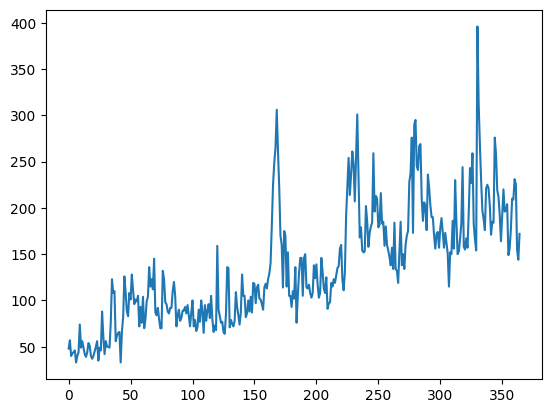

In [72]:
subs.plot()

<Axes: >

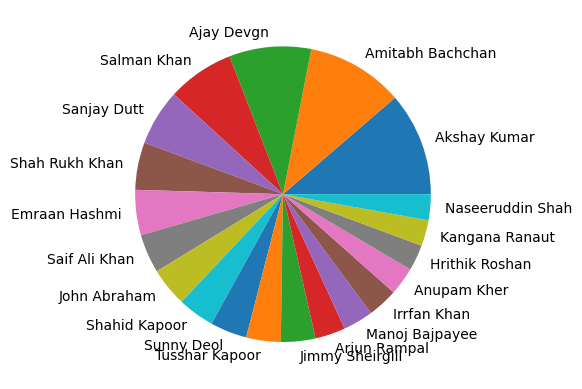

In [73]:
movies.value_counts().head(20).plot(kind='pie')

# 16. Important Series Methods

### Pandas fundamentals
Labeled axes, alignment, indexing, grouping, missing data, I/O. Critical for EDA/preprocessing.

## 16.1 isin and apply

Two methods cover a huge share of day-to-day selection and transformation.

`isin` answers membership for an entire Series at once:

```python
vk[vk.isin([49, 99])]
```

The condition `vk.isin([49, 99])` returns a boolean Series that is True wherever a value equals 49 or 99. Wrapped in brackets, it filters to exactly the near-misses — match 82 with 99 runs and match 86 with 49 runs. Notice how this replaces a manual OR chain: the notebook first writes the long form `vk[(vk == 49) | (vk == 99)]` and then shows the compact `isin` equivalent. For a long whitelist, `isin` is much cleaner than a string of equalities.

`apply` runs a function on every element:

```python
movies.apply(lambda x: x.split()[0].upper())
subs.apply(lambda x: 'good day' if x > subs.mean() else 'bad day')
```

The first function takes each actor's full name, splits it on spaces, takes the first token, and uppercases it — so `Vicky Kaushal` becomes `VICKY`. The result is a new Series with the SAME index. The second function classifies each day: above the average subscriber count yields `'good day'`, otherwise `'bad day'`. Transformations like these would otherwise require an explicit loop; `apply` turns them into a single expressive expression.

## 16.2 Duplicates and missing values

The cleaning workflow begins here, and the code runs two complementary families on small demo Series.

```python
temp = pd.Series([1, 1, 2, 2, 3, 3, 4, 4])
temp.drop_duplicates(keep='last')
temp.duplicated().sum()
```

`drop_duplicates(keep='last')` removes repeated values, keeping the LAST occurrence of each — the output keeps the second 1, the second 2, and so on. `temp.duplicated()` returns a boolean Series that marks every repeat, and `.sum()` counts the True values: 4 duplicates in the demo, and 137 in the real batting data.

Then the code builds a Series with three missing entries:

```python
temp = pd.Series([1, 2, 3, np.nan, 5, 6, np.nan, 8, np.nan, 10])
```

`temp.size` reports all 10 elements, but `temp.count()` reports 7 — size includes missing values, count skips them. `temp.isnull().sum()` reports exactly 3, the number of NaNs. `temp.dropna()` removes the missing rows entirely, and `temp.fillna(temp.mean())` replaces each NaN with the mean of the valid values, here 5.0.

The takeaway is a pipeline: detect gaps with isnull, delete them with dropna, or patch them with fillna, and always remember that size and count answer different questions about the same column.

## 16.3 astype, between, clip

This trio manages the values' type, range, and bounds.

`astype` converts the dtype:

```python
sys.getsizeof(vk)
sys.getsizeof(vk.astype('int16'))
```

The example measures memory with the standard sys module and shows the payoff of a smaller integer type: the original int64 Series occupies 3456 bytes, and the int16 version only 2166. Downcasting is a real optimization when a column's values fit a narrower range.

`between` creates an inclusive range mask:

```python
vk[vk.between(51, 99)].size
```

`vk.between(51, 99)` is True for every score from 51 through 99 inclusive, and the filter counts 43 such innings — the classic between-50-and-100 analysis, written in one word instead of two comparisons.

`clip` clamps the values inside a window:

```python
subs.clip(100, 200)
```

Every value below 100 becomes 100, and every value above 200 becomes 200; the rest pass through untouched. The output shows the earliest days pinned to 100 and the late-year spikes pinned to 200. Clipping is the standard way to tame outliers before analysis.

Remember one caution with `astype`: narrowing a type can lose precision, so only downcast when the data genuinely fits. These three methods, plus the duplicate and NaN tools, are the raw building blocks of every data-cleaning pipeline you will write.

## 16.4 isin and apply in practice

Revisit the notebook's real-data examples and the pattern becomes clear.

`vk[vk.isin([49, 99])]` filters the batting runs to 49 and 99, the annoying near-hundreds. The phrasing reads like English: keep the values that are IN this list. With `and` and `or` equivalents — the `&` and `|` operators — you can fold `isin` into bigger conditions, though every sub-expression needs parentheses.

The actor transformation chains `.split()` and `.upper()` inside a lambda, and it produces a new Series preserving the movie-title index. This is a transformation: same labels, changed values. The classification example shows `apply` hitting a different purpose — turning continuous numbers into categories by comparing each day's value to the overall mean.

A performance note is worth remembering even at this stage: `apply` invokes a Python function once per element, so it is slower than a vectorized operation that pandas can execute natively. Use `isin` and comparisons for filtering whenever they express the question; reach for `apply` when the logic genuinely needs a custom Python function, such as parsing text or combining several pieces of a row. The two methods are complementary — `isin` decides which rows to keep, `apply` decides what each kept value becomes.

## 16.5 A cleanup pipeline for missing values

The missing-value demo Series is a miniature of real data: integers, gaps, and a decision to make. The tools arrive in order of aggression.

`drop_duplicates` and `duplicated` deal with repeats. The demo keeps all four distinct values and drops the extra copies, and `vk.duplicated().sum()` quantifies how many rows repeat in the batting data. `keep='first'`, `keep='last'`, and `keep=False` (remove ALL copies) control which occurrence survives.

Missing values get a family of their own. `isnull()` returns True for each missing slot, and chaining `.sum()` turns that into a count of holes. `dropna()` deletes every row containing a NaN. `fillna(value)` patches holes with a chosen value — a constant, the mean, the median, or even a neighbour's value via methods like `bfill` (backfill, copying the next valid value) and `ffill` (forward fill, copying the previous one).

The distinction between `size` and `count` is the hidden trap: size reports everything including NaNs, count reports only valid values. When someone shows you 10 rows but count says 7, the difference of 3 is your missing-value report.

For the subscriber and cricket datasets in this notebook, the strategy is simple: inspect with `isnull().sum()`, then decide — delete the holes if they are few and unimportant, fill them with a statistic if the column is essential. Writing the cleanup as a pipeline keeps it readable and repeatable for future loads of the same file.

## 16.6 Memory and range control

This final trio is about keeping numeric data honest.

The memory comparison in the cells is worth re-reading line by line. `sys.getsizeof(vk)` measures the Python object overhead of the int64 Series at 3456 bytes; `sys.getsizeof(vk.astype('int16'))` measures the int16 version at 2166 bytes. Each element of int16 needs half the bytes of int32 and a quarter of int64, so on wide datasets dtype-tuning produces dramatic savings.

`between(51, 99)` is a filter that needs no comparison operators: it is inclusive on both ends, so a score of exactly 51 or 99 matches. Work through the equivalence once: `vk[vk.between(51, 99)]` means exactly the same as `vk[(vk >= 51) & (vk <= 99)]`. When you see `between` in someone's code, you are seeing the friendly face of two joined comparisons.

`clip(100, 200)` bounds every value into the interval. Below-trend days become 100, extreme spikes become 200, and everything in between stays untouched. It differs from `between` in a crucial way: clip CHANGES the values, whereas between only SELECTS rows. Filter the data with between; clamp the data with clip.

One warning accompanies downcasting: narrowed types can overflow or lose precision if a value exceeds the range, so profile the data first (min and max) before shrinking the dtype. With that check in place, astype, between, and clip give you precise control over type, range, and bounds.

In [74]:
# astype
# between
# clip
# drop_duplicates
# isnull
# dropna
# fillna
# isin
# apply
# copy

In [75]:
import numpy as np
import pandas as pd

In [77]:
subs = pd.read_csv('D:/GENAI/AI-Engineering-Foundations/01_Python/07_Pandas/Datasets/subs.csv').squeeze()
subs

0       48
1       57
2       40
3       43
4       44
      ... 
360    231
361    226
362    155
363    144
364    172
Name: Subscribers gained, Length: 365, dtype: int64

In [78]:
vk = pd.read_csv('D:/GENAI/AI-Engineering-Foundations/01_Python/07_Pandas/Datasets/kohli_ipl.csv',index_col='match_no').squeeze()
vk

match_no
1       1
2      23
3      13
4      12
5       1
       ..
211     0
212    20
213    73
214    25
215     7
Name: runs, Length: 215, dtype: int64

In [79]:
movies = pd.read_csv('D:/GENAI/AI-Engineering-Foundations/01_Python/07_Pandas/Datasets/bollywood.csv',index_col='movie').squeeze()
movies

movie
Uri: The Surgical Strike                   Vicky Kaushal
Battalion 609                                Vicky Ahuja
The Accidental Prime Minister (film)         Anupam Kher
Why Cheat India                            Emraan Hashmi
Evening Shadows                         Mona Ambegaonkar
                                              ...       
Hum Tumhare Hain Sanam                    Shah Rukh Khan
Aankhen (2002 film)                     Amitabh Bachchan
Saathiya (film)                             Vivek Oberoi
Company (film)                                Ajay Devgn
Awara Paagal Deewana                        Akshay Kumar
Name: lead, Length: 1500, dtype: str

In [80]:
# astype
import sys
sys.getsizeof(vk)

1884

In [81]:
sys.getsizeof(vk.astype('int16'))

594

In [82]:
# between
vk[vk.between(51,99)].size

43

In [83]:
# clip
subs

0       48
1       57
2       40
3       43
4       44
      ... 
360    231
361    226
362    155
363    144
364    172
Name: Subscribers gained, Length: 365, dtype: int64

In [84]:
subs.clip(100,200)

0      100
1      100
2      100
3      100
4      100
      ... 
360    200
361    200
362    155
363    144
364    172
Name: Subscribers gained, Length: 365, dtype: int64

In [85]:
# drop_duplicates
temp = pd.Series([1,1,2,2,3,3,4,4])
temp

0    1
1    1
2    2
3    2
4    3
5    3
6    4
7    4
dtype: int64

In [86]:
temp.drop_duplicates(keep='last')

1    1
3    2
5    3
7    4
dtype: int64

In [87]:
temp.duplicated().sum()

np.int64(4)

In [88]:
vk.duplicated().sum()

np.int64(137)

In [89]:
movies.drop_duplicates()

movie
Uri: The Surgical Strike                   Vicky Kaushal
Battalion 609                                Vicky Ahuja
The Accidental Prime Minister (film)         Anupam Kher
Why Cheat India                            Emraan Hashmi
Evening Shadows                         Mona Ambegaonkar
                                              ...       
Sssshhh...                              Tanishaa Mukerji
Rules: Pyaar Ka Superhit Formula                  Tanuja
Right Here Right Now (film)                        Ankit
Talaash: The Hunt Begins...                Rakhee Gulzar
The Pink Mirror                          Edwin Fernandes
Name: lead, Length: 566, dtype: str

In [90]:
temp = pd.Series([1,2,3,np.nan,5,6,np.nan,8,np.nan,10])
temp

0     1.0
1     2.0
2     3.0
3     NaN
4     5.0
5     6.0
6     NaN
7     8.0
8     NaN
9    10.0
dtype: float64

In [91]:
temp.size

10

In [92]:
temp.count()

np.int64(7)

In [93]:
# isnull
temp.isnull().sum()

np.int64(3)

In [94]:
# dropna
temp.dropna()

0     1.0
1     2.0
2     3.0
4     5.0
5     6.0
7     8.0
9    10.0
dtype: float64

In [95]:
# fillna
temp.fillna(temp.mean())

0     1.0
1     2.0
2     3.0
3     5.0
4     5.0
5     6.0
6     5.0
7     8.0
8     5.0
9    10.0
dtype: float64

In [96]:
# isin
vk[(vk == 49) | (vk == 99)]

match_no
82    99
86    49
Name: runs, dtype: int64

In [97]:
vk[vk.isin([49,99])]

match_no
82    99
86    49
Name: runs, dtype: int64

In [98]:
# apply
movies

movie
Uri: The Surgical Strike                   Vicky Kaushal
Battalion 609                                Vicky Ahuja
The Accidental Prime Minister (film)         Anupam Kher
Why Cheat India                            Emraan Hashmi
Evening Shadows                         Mona Ambegaonkar
                                              ...       
Hum Tumhare Hain Sanam                    Shah Rukh Khan
Aankhen (2002 film)                     Amitabh Bachchan
Saathiya (film)                             Vivek Oberoi
Company (film)                                Ajay Devgn
Awara Paagal Deewana                        Akshay Kumar
Name: lead, Length: 1500, dtype: str

In [99]:
movies.apply(lambda x:x.split()[0].upper())

movie
Uri: The Surgical Strike                  VICKY
Battalion 609                             VICKY
The Accidental Prime Minister (film)     ANUPAM
Why Cheat India                          EMRAAN
Evening Shadows                            MONA
                                         ...   
Hum Tumhare Hain Sanam                     SHAH
Aankhen (2002 film)                     AMITABH
Saathiya (film)                           VIVEK
Company (film)                             AJAY
Awara Paagal Deewana                     AKSHAY
Name: lead, Length: 1500, dtype: str

In [100]:
subs

0       48
1       57
2       40
3       43
4       44
      ... 
360    231
361    226
362    155
363    144
364    172
Name: Subscribers gained, Length: 365, dtype: int64

In [101]:
subs.apply(lambda x:'good day' if x > subs.mean() else 'bad day')

0       bad day
1       bad day
2       bad day
3       bad day
4       bad day
         ...   
360    good day
361    good day
362    good day
363    good day
364    good day
Name: Subscribers gained, Length: 365, dtype: str

In [102]:
subs.mean()

np.float64(135.64383561643837)

In [103]:

# copy

In [104]:
vk

match_no
1       1
2      23
3      13
4      12
5       1
       ..
211     0
212    20
213    73
214    25
215     7
Name: runs, Length: 215, dtype: int64

In [105]:
new = vk.head()

In [106]:
new

match_no
1     1
2    23
3    13
4    12
5     1
Name: runs, dtype: int64

In [107]:
new[1] = 1

In [108]:
new = vk.head().copy()

In [109]:

new[1] = 100

In [110]:
new

match_no
1    100
2     23
3     13
4     12
5      1
Name: runs, dtype: int64

In [111]:
vk

match_no
1       1
2      23
3      13
4      12
5       1
       ..
211     0
212    20
213    73
214    25
215     7
Name: runs, Length: 215, dtype: int64

# Summary

In this session you built the Series from the ground up: a one-dimensional labeled array — a single column with values on the right and index labels on the left. You created Series from lists, custom index and name pairs, dictionaries, and CSV files via read_csv with squeeze and index_col, and inspected them with size, dtype, name, is_unique, index, and values.

You computed the statistical toolkit of count, sum, mean, median, mode, std, var, and describe; indexed, sliced, and edited values by position and label; and used len, dict, membership, and broadcasting. Boolean masks answered questions such as how many fifties and ducks a batsman scored, and one-line plots turned numbers into charts. The important methods — isin, apply, astype, between, clip, drop_duplicates, isnull, dropna, fillna, and copy — formed a complete cleanup pipeline. The Series is now your basic labeled unit.